In [1]:
# svm environment: python scikit-learn numpy pandas matplotlib ipykernel
# git clone -b development https://github.com/peterbarkley/oars.git
# pip install .[paper]
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_20newsgroups
import pandas as pd
import matplotlib.pyplot as plt

from oars.algorithms.cara import caraStarAlgorithm
from oars.utils.cara import warpedL1Prox, hingeLossProx


In [2]:
# 1. Load a subset of the 20 Newsgroups dataset (Sparse Text Data)
categories = ['alt.atheism', 'soc.religion.christian']
data = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))
print('Loaded data')

Loaded data


In [3]:
# 2. Convert text to a Sparse Matrix (TF-IDF)
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(data.data) # This is a sparse matrix!
y = data.target
print('Vectorized data')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)
print('Split data')
print(X_train.shape)
n = X_train.shape[0] # number of samples
p = X_train.shape[1] # number of features

Vectorized data
Split data
(539, 15400)


In [4]:
# Helper functions

# Callback to store current solution
class cb():
    def __init__(self):
        self.sol = []

    def __call__(self, all_x, **kwargs):
        self.sol.append(all_x[0].copy())

# Scoring function
def score(xtest, ytest, weights):
    res = xtest@weights
    predictions = (res > 0).astype(int)
    return np.mean(predictions == ytest)


In [42]:
column_counts = X_train.getnnz(axis=0)
counts = column_counts.copy()
counts[column_counts == 0] = 1 #(to avoid divide by zero)

hingeData = [{'varlist': X_train[i].indices , 'a': X_train[i].data, 'b': 2*y_train[i]-1 } for i in range(n) if len(X_train[i].data) > 0] # data for each hinge loss function (uses 1/-1 vice 1/0 for labels)

lData =  [{'varlist': range(p), 'D': counts, 'scale':0.5}] # data for box projection, scale sets the weight of the regularizer
caradata = lData + hingeData
    
A = [warpedL1Prox] + [hingeLossProx for i in range(n) if len(X_train[i].data) > 0]
cbcara = cb()
y_cara, all_v_cara = caraStarAlgorithm(caradata, A, itrs=500, gamma=1.4, verbose=True, callback=cbcara)

date		time		itr	||x-bar(x)||	||sum dual||


2026-03-03 13:34:38.829325	49	3.574e-01	4.099e+00
2026-03-03 13:34:39.198561	99	1.965e-01	2.803e+00
2026-03-03 13:34:39.563237	149	1.530e-01	1.961e+00
2026-03-03 13:34:39.927766	199	1.152e-01	1.643e+00
2026-03-03 13:34:40.295315	249	9.615e-02	1.384e+00
2026-03-03 13:34:40.664004	299	7.995e-02	1.104e+00
2026-03-03 13:34:41.030517	349	6.945e-02	8.638e-01
2026-03-03 13:34:41.401252	399	5.946e-02	7.233e-01
2026-03-03 13:34:41.768018	449	5.113e-02	6.815e-01
2026-03-03 13:34:42.133234	499	4.978e-02	5.984e-01


In [43]:
score(X_test, y_test, y_cara)

np.float64(0.8203703703703704)

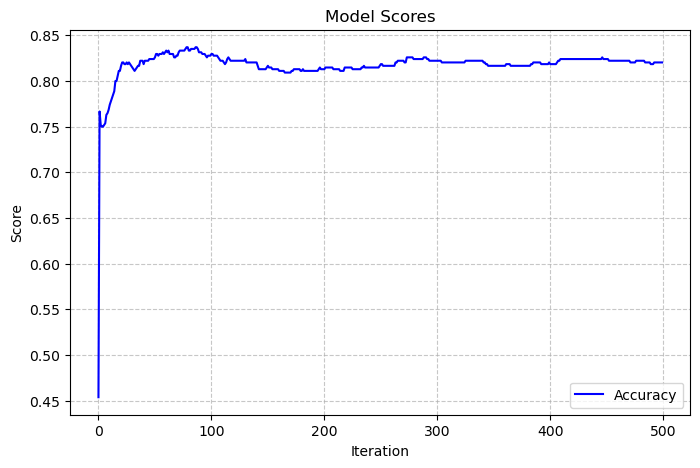

In [44]:
scores = [score(X_test, y_test, wt) for wt in cbcara.sol]

plt.figure(figsize=(8, 5))
plt.plot(scores, linestyle='-', color='b', label='Accuracy')

# Add labels and title
plt.title('Model Scores')
plt.xlabel('Iteration')
plt.ylabel('Score')

# Add a grid for easier reading
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Display the plot
plt.show()

In [45]:
# Features:
num_zeros = np.sum(np.abs(y_cara) < 1e-9)

sparsity_percentage = (num_zeros / p) * 100

print(f"The l1 model ignored {num_zeros} out of {p} features ({sparsity_percentage:.2f}% sparse).")

The l1 model ignored 15129 out of 15400 features (98.24% sparse).


In [46]:
features = vectorizer.get_feature_names_out()

# Convert to a DataFrame for easy sorting
dfc = pd.DataFrame({'word': features, 'weight': y_cara})

# Get the top 10 for each class
top_class_1 = dfc.sort_values(by='weight', ascending=False).head(10)
top_class_0 = dfc.sort_values(by='weight', ascending=True).head(10)

print("Top words for Class 1:\n", top_class_1)
print("\nTop words for Class 0:\n", top_class_0)

Top words for Class 1:
                 word    weight
2765      christians  5.240622
2786          church  5.109027
3769        cultural  4.495900
2761       christian  4.269260
7844           jesus  4.203275
2755          christ  3.665268
13850         thanks  3.625495
14461  understanding  3.545950
10222           paul  2.882038
8509            lord  2.841040

Top words for Class 0:
            word    weight
13765     tells -4.339020
10596    policy -4.048849
8649   majority -3.985934
12055      risk -3.798128
14030        tm -3.532591
1528    atheism -3.502564
8422       list -3.460608
13886    theory -3.445535
14806  versions -3.251989
1532   atheists -3.232113


In [37]:
# Compare to an SGD fit on a similar model
from sklearn.linear_model import SGDClassifier

# Set loss to 'hinge' (Standard SVM) 
# Set penalty to 'l1' (Lasso-style sparsity)

clf = SGDClassifier(loss='hinge', penalty='l1', alpha=0.001, fit_intercept=False, random_state=0, max_iter=3000)

clf.fit(X_train, y_train)

print(f"Model Accuracy: {clf.score(X_test, y_test):.2%}")

Model Accuracy: 80.37%


In [39]:
# Model sparsity
num_zeros = np.sum(np.abs(clf.coef_) < 1e-9)
total_features = clf.coef_.size
sparsity_percentage = (num_zeros / total_features) * 100

print(f"The SGD model ignored {num_zeros} out of {total_features} features ({sparsity_percentage:.2f}% sparse).")

The SGD model ignored 15152 out of 15400 features (98.39% sparse).


In [40]:
# Top words
weights = clf.coef_[0] 
feature_weights = dict(zip(features, weights))

# Convert to a DataFrame for easy sorting
df = pd.DataFrame({'word': features, 'weight': weights})

# Get the top 10 for each class
top_class_1 = df.sort_values(by='weight', ascending=False).head(10)
top_class_0 = df.sort_values(by='weight', ascending=True).head(10)

print("Top words for Class 1:\n", top_class_1)
print("\nTop words for Class 0:\n", top_class_0)

Top words for Class 1:
                 word    weight
2765      christians  6.294822
2786          church  5.663907
2761       christian  5.380944
2755          christ  4.336295
7844           jesus  4.061017
14965           want  3.727981
14461  understanding  2.881815
8509            lord  2.863524
13850         thanks  2.740608
5231         eternal  2.683144

Top words for Class 0:
            word    weight
4638        don -4.619503
1528    atheism -3.763276
12036     right -3.316808
7737      islam -3.235314
13765     tells -3.143555
12055      risk -2.949170
8422       list -2.941510
8548    lucifer -2.803695
1532   atheists -2.703188
15272    wouldn -2.662853
